In [1]:
import torch
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments, ViTImageProcessor, BertTokenizer, VisionEncoderDecoderModel

import torch
from torch.utils.data import Dataset
import os
import cv2
import numpy as np

from PIL import Image, ImageFile
from tqdm import tqdm
import xml.etree.ElementTree as ET


import re

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from plant_dataset import load_sideview_images
from image_process import process_leaf_image
from plant_tokenizer import vec2token, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, VOCAB_SIZE
from string_to_xml_to_vec import xml2vec, linked_to_recursive
from plant_dataset import PlantDataset

# Dataset 인스턴스 생성
if 0:
    growth_stages = ["01"]
else:
    growth_stages = None
image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from transformers import VisionEncoderDecoderModel
from utils import model_summary

#checkpoint_path = "../log/20250321_Quantized_dataset_PlantMeta/results"
checkpoint_path = "../log/20250322_Quantized_dataset_PlantMeta_TotalData/results/checkpoint-7000"
model = VisionEncoderDecoderModel.from_pretrained(checkpoint_path).to(device)
# Set the model to evaluation mode
model.eval()

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_featur

In [3]:
model_summary(model)

  | Name    | Type            | Params | Mode
---------------------------------------------------
0 | encoder | ViTModel        | 86.4 M | eval
1 | decoder | BertLMHeadModel | 116 M  | eval
---------------------------------------------------
202 M     Trainable params
0         Non-trainable params
202 M     Total params
809.592   Total estimated model params size (MB)
0         Modules in train mode
580       Modules in eval mode


In [4]:
from torch.utils.data import random_split
# Set a random seed for reproducibility
seed = 42
torch.manual_seed(seed)

# Dataset 인스턴스 생성
if 0:
    growth_stages = ["01"]
else:
    growth_stages = None
dataset = PlantDataset(root_dir="../data/2000_Plots_20241210_Quantized", stages=growth_stages, 
                       process_leaf=True,
                       preload=False, image_processor=image_processor, add_sos_token=False)

# Split the dataset into Train, Validation, and Test sets
train_size = int(0.8 * len(dataset))  # 80% for training
val_size = int(0.1 * len(dataset))    # 10% for validation
test_size = len(dataset) - train_size - val_size  # Remaining 10% for testing

# Use random_split with the seed set above
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

Total 40000 images and plant strings loaded


tensor([[87, 88, 67, 78, 79, 88,  0, 73, 82, 82, 73, 72,  1, 56, 40, 35, 81,  2,
         36, 39, 78, 31, 72,  3, 55, 34, 35, 33,  6, 35, 35, 79, 73, 73,  7, 48,
         40, 76, 82,  8, 55, 39, 77, 28, 71,  9, 55, 34, 74, 33, 10, 56, 34, 35,
         33, 11, 55, 35, 34, 33,  7, 48, 40, 76, 81,  8, 55, 39, 77, 28, 71,  9,
         55, 34, 74, 33, 10, 56, 34, 35, 33, 11, 55, 34, 34, 33,  7, 48, 40, 76,
         81,  8, 55, 39, 77, 28, 71,  9, 55, 34, 74, 33, 10, 56, 34, 35, 33, 11,
         55, 35, 34, 33,  7, 46, 40, 76, 82,  8, 54, 38, 77, 28, 71,  9, 54, 34,
         74, 33, 10, 55, 34, 35, 33, 11, 54, 34, 34, 33,  7, 37, 40, 76, 81,  8,
         44, 35, 77, 31, 71,  9, 45, 34, 74, 33, 10, 45, 34, 35, 33, 11, 45, 34,
         34, 33,  6, 77, 34, 79, 73, 73,  7, 49, 40, 76, 82,  8, 54, 38, 77, 28,
         71,  9, 54, 34, 74, 33, 10, 55, 34, 35, 33, 11, 54, 34, 34, 33,  7, 37,
         40, 76, 82,  8, 44, 35, 77, 28, 71,  9, 45, 34, 74, 33, 10, 45, 34, 35,
         33, 11, 45, 34, 34,

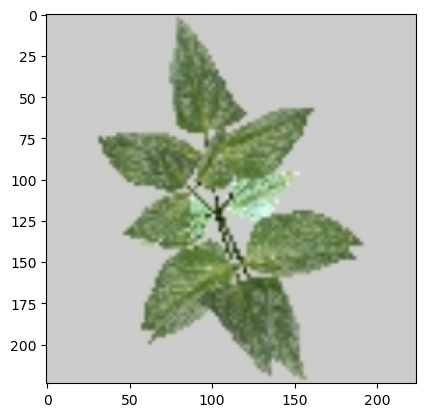

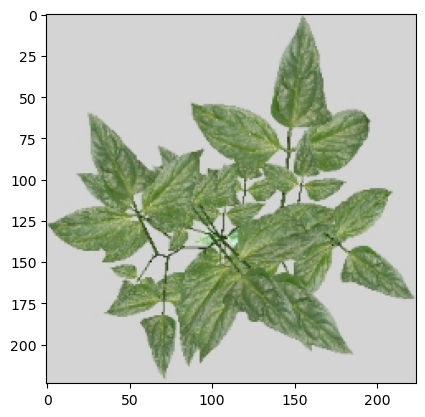

In [ ]:
import matplotlib.pyplot as plt
for i in range(2):
    pixel_values = test_dataset[i]["pixel_values"].unsqueeze(0).to(model.device)
    plant_info = test_dataset[i]["plant_info"]
    plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens
    generated_ids = model.generate(pixel_values,
                                decoder_start_token_id=SOS_TOKEN,
                                decoder_input_ids=plant_info,
                                eos_token_id=EOS_TOKEN,
                                max_length=2500
                                )
    print(generated_ids)

    image_vis = pixel_values.squeeze().permute(1,2,0).cpu().numpy()
    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    plt.figure()
    plt.imshow(image_vis)


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_0_gt
Debug: false
Grow: false
View height: 1m
Tile file: none
Loading plant architecture XML file: /home/lion397/codes/Image2PlantArchitecture/src/temp/plant_0_gt.xml...done.
Plant Height: 0.0772908
Stem Height: 0.0300124
Leaf count: 29
Leaf area: 0.00349739
Leaf inclination: 0.0805806 0.2139 0.109998 0.162695 0.260337 0.0801692 0.0678888 0.0111492 0.00813261 0.0051495 


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_0_est
Debug: false
Grow: false
View height: 1m
Tile file: none
Loading plant architecture XML file: /home/lion397/codes/Image2PlantArchitecture/src/temp/plant_0_est.xml...done.
Plant Height: 0.0649174
Stem Height: 0.0300095
Leaf count: 29
Leaf area: 0.00407832
Leaf inclination: 0.0679743 0.24617 0.246884 0.200584 0.162207 0.0231304 0.0213826 0.0131243 0.0150582 0.00348496 


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_1

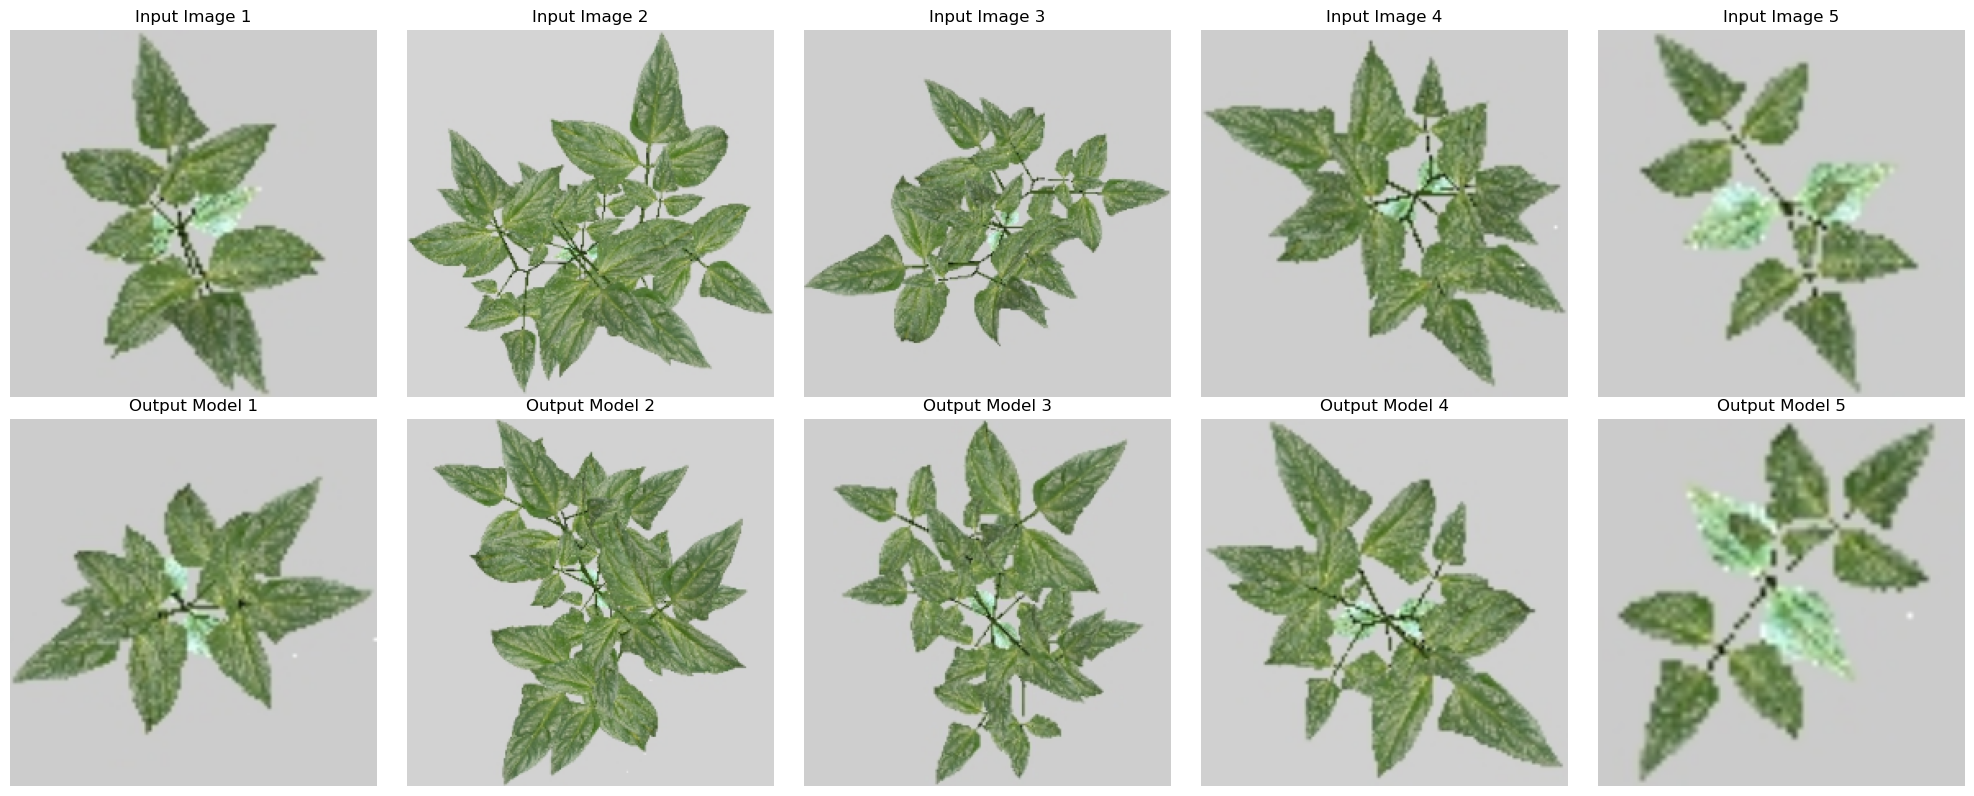

In [6]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_TOKEN, EOS_TOKEN
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked
from plant_tokenizer import token2vec
import subprocess
import shutil
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml

  
program_path = "../src/GenerateDataset/build"
# Function to re-render a single XML file
def re_render_xml(output_path, filename, rotation=True):
    image_name = filename.split("/")[-1].split(".")[0]
    os.environ["DISPLAY"] = ":11.0"
    #os.environ["DISPLAY"] = ":1.0"
    # Generate image 
    # Construct the command
    command = ""
    command += f"cd {program_path} && ./main " 
    command += f"-h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    #command += f"-h 1.0 -o {output_path} -name {image_name} -tile black -f {os.path.join(output_path, filename)}"
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    return result

# Prepare the figure
n_figures = 5
fig, axes = plt.subplots(2, n_figures, figsize=(20, 8))

# Create temp folder
temp_folder = "temp"
shutil.rmtree(temp_folder, ignore_errors=True)
os.makedirs(temp_folder, exist_ok=True)

image_size = 224
device = model.device
for idx, data in enumerate(test_dataset):
    if idx >= n_figures:
        break
    image = data["pixel_values"]
    out = data["labels"]
    plant_info = data["plant_info"]
    # print(dataloader.dataset.plant_xml_files[idx])
    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)
    out = torch.tensor(out).to(device)
    ground_truth = out.squeeze(0).cpu().numpy()

    plant_vec = token2vec(ground_truth[5:])
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_gt.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    if 1:
        re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
        img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
        if 1:
            leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=True)
            img = cv2.resize(leaf_img, (image_size, image_size))
        else:
            img = cv2.resize(img, (image_size, image_size))
        gt_img = img.copy()
    
    ############## Generate

    with torch.no_grad():
        plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens
        result = model.generate(image,
                                decoder_start_token_id=SOS_TOKEN,
                                decoder_input_ids=plant_info,
                                eos_token_id=EOS_TOKEN,
                                max_length=2500
                                )
        result = result.squeeze().cpu().numpy()[6:]

    plant_vec = token2vec(result)
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_est.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))

    if 0:
        img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), 224, True)
    else:
        if 1:
            img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=True)
            img = cv2.resize(leaf_img, (image_size, image_size))
        else:
            img = cv2.resize(img, (image_size, image_size))

    image_vis = image[0].permute(1, 2, 0).cpu()
    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)


    row, col = divmod(idx, n_figures)
    axes[row, col].imshow(image_vis[:, :, 0:3])
    axes[row, col].set_title(f"Input Image {idx + 1}")
    axes[row, col].axis('off')
   
    img = cv2.normalize(img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    axes[row + 1, col].imshow(img)
    axes[row + 1, col].set_title(f"Output Model {idx + 1}")
    axes[row + 1, col].axis('off')

plt.tight_layout()
plt.show()

Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_0_gt
Debug: false
Grow: false
View height: 1m
Tile file: none
Loading plant architecture XML file: /home/lion397/codes/Image2PlantArchitecture/src/temp/plant_0_gt.xml...done.
Plant Height: 0.0772908
Stem Height: 0.0300124
Leaf count: 29
Leaf area: 0.00349739
Leaf inclination: 0.0805806 0.2139 0.109998 0.162695 0.260337 0.0801692 0.0678888 0.0111492 0.00813261 0.0051495 


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_0_est
Debug: false
Grow: false
View height: 1m
Tile file: none
Loading plant architecture XML file: /home/lion397/codes/Image2PlantArchitecture/src/temp/plant_0_est.xml...done.
Plant Height: 0.0649174
Stem Height: 0.0300095
Leaf count: 29
Leaf area: 0.00378523
Leaf inclination: 0.0408337 0.283502 0.271135 0.189509 0.136477 0.022089 0.0274411 0.0108598 0.0148096 0.0033442 


Save dir: /home/lion397/codes/Image2PlantArchitecture/src/temp
Output name: plant_1_

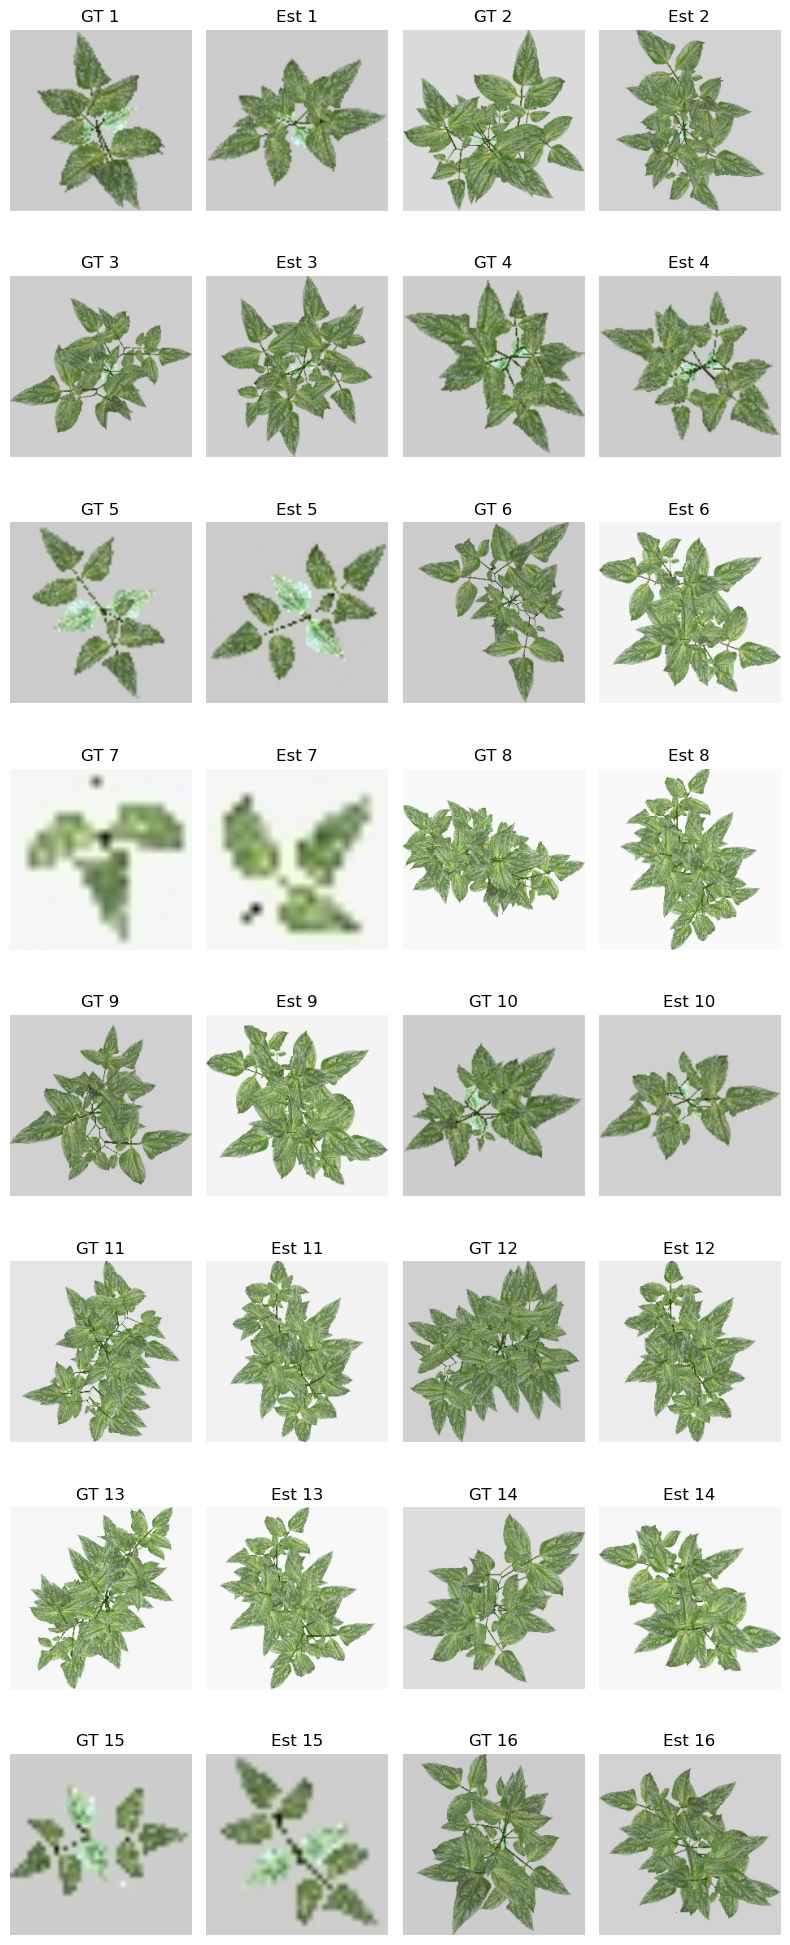

In [11]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_TOKEN, EOS_TOKEN
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked, pretty_print_xml
from plant_tokenizer import token2vec
import subprocess
import shutil

# Constants
PROGRAM_PATH = "../src/GenerateDataset/build"
TEMP_FOLDER = "temp"
IMAGE_SIZE = 224
N_FIGURES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure temp folder exists
def prepare_temp_folder(folder_path):
    shutil.rmtree(folder_path, ignore_errors=True)
    os.makedirs(folder_path, exist_ok=True)

# Re-render a single XML file
def re_render_xml(output_path, filename, rotation=True):
    image_name = filename.split("/")[-1].split(".")[0]
    os.environ["DISPLAY"] = ":11.0"
    command = (
        f"cd {PROGRAM_PATH} && ./main "
        f"-h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    )
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    return result

# Save XML file
def save_xml_file(xml_data, file_path):
    xml_str = pretty_print_xml(xml_data)
    with open(file_path, "w") as f:
        f.write(xml_str)

# Process ground truth data
def process_ground_truth(data, idx):
    ground_truth = data["labels"]
    plant_vec = token2vec(ground_truth[5:])
    plant_xml = vec2xml(plant_vec)
    plant_xml = recursive_to_linked(plant_xml)
    xml_file_name = f"{TEMP_FOLDER}/plant_{idx}_gt.xml"
    save_xml_file(plant_xml, xml_file_name)
    return xml_file_name

# Process generated data
def process_generated_data(model, image, plant_info, idx):
    with torch.no_grad():
        plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(DEVICE)
        result = model.generate(
            image,
            decoder_start_token_id=SOS_TOKEN,
            decoder_input_ids=plant_info,
            eos_token_id=EOS_TOKEN,
            max_length=2500,
        )
        result = result.squeeze().cpu().numpy()[5:]
    plant_vec = token2vec(result)
    plant_xml = vec2xml(plant_vec)
    plant_xml = recursive_to_linked(plant_xml)
    xml_file_name = f"{TEMP_FOLDER}/plant_{idx}_est.xml"
    save_xml_file(plant_xml, xml_file_name)
    return xml_file_name

# Visualize images
def visualize_images(gt_img, est_img, axes, idx):
    row, col = divmod(idx, 2)
    col *= 2  # Each figure has 2 rows (gt and est)

    # Ground Truth
    gt_img = cv2.normalize(gt_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    axes[row, col].imshow(gt_img)
    axes[row, col].set_title(f"GT {idx + 1}")
    axes[row, col].axis("off")

    # Estimated Output
    est_img = cv2.normalize(est_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    axes[row, col+1].imshow(est_img)
    axes[row, col+1].set_title(f"Est {idx + 1}")
    axes[row, col+1].axis("off")

# Main function
def main(model, test_dataset):
    prepare_temp_folder(TEMP_FOLDER)
    fig, axes = plt.subplots(2 * N_FIGURES, 4, figsize=(8, 20))

    for idx, data in enumerate(test_dataset):
        if idx >= N_FIGURES * 4:
            break

        image = data["pixel_values"].unsqueeze(0).to(DEVICE)
        plant_info = data["plant_info"]

        # Process ground truth
        gt_xml_file = process_ground_truth(data, idx)
        re_render_xml(os.path.abspath(TEMP_FOLDER), os.path.abspath(gt_xml_file))
        gt_img = cv2.imread(gt_xml_file.replace("xml", "jpeg"))
        gt_img = cv2.cvtColor(gt_img, cv2.COLOR_RGB2BGR)
        leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(gt_img, sqaure_crop=True)
        gt_img = cv2.resize(leaf_img, (IMAGE_SIZE, IMAGE_SIZE))

        # Process generated data
        gen_xml_file = process_generated_data(model, image, plant_info, idx)
        re_render_xml(os.path.abspath(TEMP_FOLDER), os.path.abspath(gen_xml_file))
        est_img = cv2.imread(gen_xml_file.replace("xml", "jpeg"))
        est_img = cv2.cvtColor(est_img, cv2.COLOR_RGB2BGR)
        leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(est_img, sqaure_crop=True)
        est_img = cv2.resize(leaf_img, (IMAGE_SIZE, IMAGE_SIZE))

        # Visualize
        visualize_images(gt_img, est_img, axes, idx)

    plt.tight_layout()
    plt.show()

# Run the main function
main(model, test_dataset)